# Metadata baseline model

In [181]:
import numpy as np
import pandas as pd

### Load split data

In [182]:
train_df = pd.read_csv(
    "data/train_df.csv",
    parse_dates=["publish_timestamp"]  # converts datestime string into datetime object
)
test_df = pd.read_csv(
    "data/test_df.csv",
    parse_dates=["publish_timestamp"]
)


In [183]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1471 entries, 0 to 1470
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   1471 non-null   int64         
 1   following                 1471 non-null   int64         
 2   publish_timestamp         1471 non-null   datetime64[ns]
 3   has_location              1471 non-null   int64         
 4   is_carousel               1471 non-null   int64         
 5   num_images                1471 non-null   int64         
 6   is_sponsored              1471 non-null   int64         
 7   image_path                1471 non-null   object        
 8   caption                   1443 non-null   object        
 9   follower_following_ratio  1471 non-null   float64       
 10  hour                      1471 non-null   int64         
 11  day                       1471 non-null   object        
 12  is_weekend          

### Define column groups to be used in metadata baseline model

In [184]:
numeric_cols = [
    "following",
    "follower_following_ratio",
    "is_weekend",
    "has_location",
    "is_carousel",
    "num_images",
    "is_sponsored",
    "caption_word_count",
    "num_hashtags"
]

categorical_cols = ["day", "hour"]


# Set random seed

In [185]:
# Set random seed
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU

    # Ensure deterministic behavior (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed(42)

### Preprocessor

In [186]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)


In [187]:
# select input features from dataframe
X_train = train_df[numeric_cols + categorical_cols]
X_test  = test_df[numeric_cols + categorical_cols]

# apply preprocessing
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)


In [188]:
# check that column size increased due to encoding
# (number_of_samples, number_of_features_after_encoding)
X_train_proc.shape

(1471, 40)

In [189]:
# select target label from dataframe
y_train = train_df["engagement_label"].values
y_test  = test_df["engagement_label"].values

### Convert preprocessed features into PyTorch tensors

In [190]:
import torch
from torch.utils.data import Dataset, DataLoader

class MetadataDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y) # num of samples in dataset

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx] # return sample at index


In [191]:
# set seed for dataloader shuffling order to make it deterministic
g = torch.Generator()
g.manual_seed(42)

In [192]:
# Creating dataset objects
train_ds = MetadataDataset(X_train_proc, y_train)
test_ds  = MetadataDataset(X_test_proc, y_test)

# DataLoader splits data into batches
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g) # randomize order every epoch
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False) # predictable evaluation


In [193]:
import torch.nn as nn

class MetadataMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1=64, hidden_dim2=32, dropout=0.3): # input_dim is number of processed features
        super().__init__()          # call constructor of nn.Module
        self.net = nn.Sequential(   # stacks layers in order
            nn.Linear(input_dim, hidden_dim1),   # Fully connected layer (40 features -> 64 hidden units)
            nn.ReLU(),                  # ReLU for non-linearity to learn complex patterns
            nn.Dropout(dropout),            # randomly drop 30% of neurons to prevent overfitting
            nn.Linear(hidden_dim1, hidden_dim2),          # 2nd hidden layer, compresses information
            nn.ReLU(),
            nn.Linear(hidden_dim2, 3)            # output layer, 3 engagement classes, outputs logits.
        )

    def forward(self, x): # forward pass
        return self.net(x)


In [194]:
# class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.unique(y_train)   # e.g. [0, 1, 2]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)


tensor([1.0613, 0.9886, 0.9558], device='cuda:0')


In [195]:
device = "cuda" if torch.cuda.is_available() else "cpu" # use GPU if available

# Input size matching one-hot expanded features
input_dim = X_train_proc.shape[1]

# Instantiate model, move weights to device
model = MetadataMLP(input_dim).to(device) # default parameters
              
# Set loss function
criterion = nn.CrossEntropyLoss(weight=class_weights) # multiclass classification, labels are integers, logits are raw scores
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # learning rate 0.001 is standard

In [196]:
print(model)

MetadataMLP(
  (net): Sequential(
    (0): Linear(in_features=40, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [197]:


# training loop
def train_epoch(loader):
    # Put model in training mode
    model.train()

    # Initialize accumulator for total loss
    total_loss = 0

    # Loops over batches in training set
    for X, y in loader:
        # Moves x y to same device
        X, y = X.to(device), y.to(device)

        # Clear old gradients from previous batch
        optimizer.zero_grad()

        # Feeds batch into model, perform forward pass, output logits
        logits = model(X)

        # Compute loss for this batch
        loss = criterion(logits, y)

        # Performs backpropagation: computes gradients of the loss with respect to each model parameter.
        loss.backward()

        # Updates model parameters using those gradients
        optimizer.step()

        # Adds the numeric loss value (converted from a tensor with .item()) to the total loss accumulator.
        total_loss += loss.item()

    # Average loss = total loss / number of batches
    avg_loss = total_loss / len(loader)
    
    return avg_loss




In [198]:
def test_epoch(loader):
    # Set model to evaluation mode. Disables dropout, freezes batchnorm stats
    model.eval()

    # Initialize accumulator for total loss
    total_loss = 0

    with torch.no_grad(): # Disables gradient tracking inside this block.
    # This saves memory and time, since we don’t need gradients for validation.
    # It also ensures the model’s weights won’t accidentally be updated.
        for X, y in loader:
            X, y = X.to(device), y.to(device)
 
            logits = model(X)

            total_loss += criterion(logits, y).item()

    # Compute average loss
    avg_loss = total_loss / len(loader)
    
    return avg_loss

In [199]:
from sklearn.metrics import confusion_matrix, f1_score

def evaluate_metrics(loader, model):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            logits = model(X)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Accuracy
    correct = sum(p == y for p, y in zip(all_preds, all_labels))
    accuracy = correct / len(all_labels)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Macro F1
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return accuracy, cm, macro_f1


In [ ]:
results = []
best_row = None

for epoch in range(10):
    train_loss = train_epoch(train_loader)
    test_loss  = test_epoch(test_loader)

    # Metrics
    train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
    test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

    best_row = {
        "model": "Baseline MLP",
        "best_epoch": epoch + 1,
        "train_macro_f1": train_macro_f1,
        "train_acc": train_acc,
        "train_cm": train_cm,
        "test_macro_f1": test_macro_f1,
        "test_acc": test_acc,
        "test_cm": test_cm,
    }
    results.append(best_row)

    print(f"\nEpoch {epoch+1}")
    print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
    print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")

    print("Train Confusion Matrix:")
    print(train_cm)

    print("Test Confusion Matrix:")
    print(test_cm)

df_baseline = pd.DataFrame(results)


Epoch 1
Train   | loss=1.0835, acc=0.484, macro-F1=0.464
Test    | loss=1.0602, acc=0.473, macro-F1=0.464
Train Confusion Matrix:
[[133 157 172]
 [ 73 207 216]
 [ 39 102 372]]
Test Confusion Matrix:
[[42 52 53]
 [13 54 47]
 [11 22 82]]

Epoch 2
Train   | loss=1.0398, acc=0.538, macro-F1=0.522
Test    | loss=0.9992, acc=0.503, macro-F1=0.485
Train Confusion Matrix:
[[263  77 122]
 [129 151 216]
 [ 78  57 378]]
Test Confusion Matrix:
[[71 31 45]
 [29 33 52]
 [15 15 85]]

Epoch 3
Train   | loss=0.9904, acc=0.554, macro-F1=0.526
Test    | loss=0.9479, acc=0.532, macro-F1=0.498
Train Confusion Matrix:
[[315  57  90]
 [168 117 211]
 [ 99  31 383]]
Test Confusion Matrix:
[[85 28 34]
 [35 24 55]
 [17  7 91]]

Epoch 4
Train   | loss=0.9558, acc=0.583, macro-F1=0.570
Test    | loss=0.9246, acc=0.585, macro-F1=0.574
Train Confusion Matrix:
[[324  73  65]
 [168 173 155]
 [ 99  54 360]]
Test Confusion Matrix:
[[89 36 22]
 [32 45 37]
 [15 14 86]]

Epoch 5
Train   | loss=0.9335, acc=0.585, macro-F1=

In [201]:
# Best model by test macro F1
best_row = df_baseline.loc[df_baseline["test_macro_f1"].idxmax()]
print(best_row)

model                                                Baseline BERT
best_epoch                                                       6
train_macro_f1                                            0.592468
train_acc                                                 0.605031
train_cm          [[357, 51, 54], [185, 182, 129], [100, 62, 351]]
test_macro_f1                                             0.576548
test_acc                                                  0.595745
test_cm                [[103, 29, 15], [42, 39, 33], [20, 13, 82]]
Name: 5, dtype: object


In [202]:
# Rank models by test macro F1
df_baseline.sort_values("test_macro_f1", ascending=False).head(5)

,model,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm
5,Baseline BERT,6,0.592468,0.605031,"[[357, 51, 54], [185, 182, 129], [100, 62, 351]]",0.576548,0.595745,"[[103, 29, 15], [42, 39, 33], [20, 13, 82]]"
3,Baseline BERT,4,0.569598,0.582597,"[[324, 73, 65], [168, 173, 155], [99, 54, 360]]",0.573712,0.585106,"[[89, 36, 22], [32, 45, 37], [15, 14, 86]]"
4,Baseline BERT,5,0.565212,0.585316,"[[380, 37, 45], [225, 147, 124], [127, 52, 334]]",0.565825,0.595745,"[[115, 20, 12], [51, 33, 30], [25, 14, 76]]"
7,Baseline BERT,8,0.585689,0.607070,"[[362, 36, 64], [184, 153, 159], [99, 36, 378]]",0.554558,0.585106,"[[104, 22, 21], [42, 31, 41], [20, 10, 85]]"
8,Baseline BERT,9,0.613474,0.626785,"[[369, 42, 51], [177, 188, 131], [94, 54, 365]]",0.553131,0.569149,"[[95, 37, 15], [40, 38, 36], [20, 14, 81]]"


# Performance Tuning

### Set fixed variables

In [167]:
# set seed for dataloader shuffling order to make it deterministic
g = torch.Generator()
g.manual_seed(42)

In [168]:
# Creating dataset objects
train_ds = MetadataDataset(X_train_proc, y_train)
test_ds  = MetadataDataset(X_test_proc, y_test)

# DataLoader splits data into batches
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g) # randomize order every epoch
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False) # predictable evaluation

In [169]:
# class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.unique(y_train)   # e.g. [0, 1, 2]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)


tensor([1.0613, 0.9886, 0.9558], device='cuda:0')


In [170]:
device = "cuda" if torch.cuda.is_available() else "cpu" # use GPU if available

# Input size matching one-hot expanded features
input_dim = X_train_proc.shape[1]

# # Instantiate model, move weights to device
# model = MetadataMLP(input_dim).to(device)

# Set loss function
criterion = nn.CrossEntropyLoss(weight=class_weights) # multiclass classification, labels are integers, logits are raw scores
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # learning rate 0.001 is standard

### Tuning loop

In [171]:
import copy
import matplotlib.pyplot as plt

results = []
best_state = None
global_best_f1 = 0


patience = 5 # stop if no improvement after 5 epochs

# Initialize plot
plt.figure(figsize=(8,5))

for hidden_dim1 in [32, 64, 128]:
    for hidden_dim2 in [16, 32, 64]:
        for dropout in [0.3, 0.5]:
            for learning_rate in [1e-3, 5e-4]:
                print("\n=====\nNew tuning parameters: ")
                print(f"dropout: {dropout}")
                print(f"learning_rate: {learning_rate}\n")

                # Instantiate model, move weights to device
                model = MetadataMLP(input_dim, hidden_dim1=hidden_dim1, hidden_dim2=hidden_dim2, dropout=dropout).to(device)

                optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # learning rate 0.001 is standard

                print(model)

                # Re-initialize metrics before epochs
                best_test_f1 = 0
                best_row = None
                no_improve_epochs = 0
                train_macro_f1_list = []
                test_macro_f1_list = []

                for epoch in range(50):
                    train_loss = train_epoch(train_loader)
                    test_loss  = test_epoch(test_loader)

                    # Metrics
                    train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
                    test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

                    # Keep metrics for plotting
                    train_macro_f1_list.append(train_macro_f1)
                    test_macro_f1_list.append(test_macro_f1)

                    if test_macro_f1 > best_test_f1:
                        # Update best F1
                        best_test_f1 = test_macro_f1
                        # Save model metrics and parameters for plot/chart
                        best_row = {
                            "model": "MLP",
                            "dropout": dropout,
                            "learning_rate": learning_rate,
                            "hidden_dim1": hidden_dim1,
                            "hidden_dim2": hidden_dim2,
                            "best_epoch": epoch + 1,
                            "train_macro_f1": train_macro_f1,
                            "train_acc": train_acc,
                            "train_cm": train_cm,
                            "test_macro_f1": test_macro_f1,
                            "test_acc": test_acc,
                            "test_cm": test_cm,

                            "train_f1_history": train_macro_f1_list.copy(),
                            "test_f1_history": test_macro_f1_list.copy(),
                        }
                        no_improve_epochs = 0  # reset patience counter
                        if test_macro_f1 > global_best_f1:
                            # Update global best F1
                            global_best_f1 = test_macro_f1
                            # Save model state for loading later using load_state_dict
                            best_state = copy.deepcopy(model.state_dict())
                    else:
                        no_improve_epochs += 1

                    

                    print(f"\nEpoch {epoch+1}")
                    print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
                    print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")
                    
                    print("Train Confusion Matrix:")
                    print(train_cm)

                    print("Test Confusion Matrix:")
                    print(test_cm)

                    if no_improve_epochs >= patience:
                        print(f"Early stopping at epoch {epoch+1}")
                        break
                            
                # Keep only the best epoch of the parameter configuration
                results.append(best_row)

            
df_results = pd.DataFrame(results)
torch.save(best_state, "best_mlp_model.pt")


=====
New tuning parameters: 
dropout: 0.3
learning_rate: 0.001

MetadataMLP(
  (net): Sequential(
    (0): Linear(in_features=40, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=3, bias=True)
  )
)

Epoch 1
Train   | loss=1.0979, acc=0.472, macro-F1=0.406
Test    | loss=1.0811, acc=0.492, macro-F1=0.398
Train Confusion Matrix:
[[347   7 108]
 [248  28 220]
 [174  19 320]]
Test Confusion Matrix:
[[109   2  36]
 [ 57   3  54]
 [ 39   3  73]]

Epoch 2
Train   | loss=1.0755, acc=0.506, macro-F1=0.486
Test    | loss=1.0555, acc=0.505, macro-F1=0.467
Train Confusion Matrix:
[[302  34 126]
 [161 116 219]
 [105  81 327]]
Test Confusion Matrix:
[[87 12 48]
 [39 20 55]
 [17 15 83]]

Epoch 3
Train   | loss=1.0394, acc=0.538, macro-F1=0.508
Test    | loss=1.0125, acc=0.529, macro-F1=0.484
Train Confusion Matrix:
[[318  30 114]
 [166 106 224]


<Figure size 800x500 with 0 Axes>

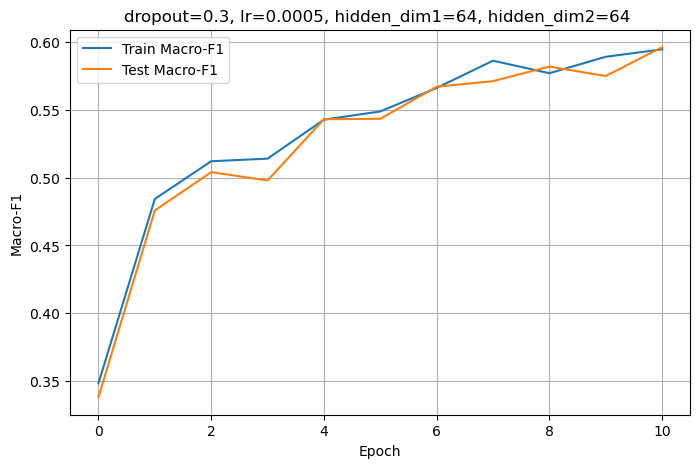

In [172]:
best_run = max(results, key=lambda x: x["test_macro_f1"])

plt.figure(figsize=(8,5))
plt.plot(best_run["train_f1_history"], label="Train Macro-F1")
plt.plot(best_run["test_f1_history"], label="Test Macro-F1")

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title(
    f"dropout={best_run['dropout']}, "
    f"lr={best_run['learning_rate']}, "
    f"hidden_dim1={best_run['hidden_dim1']}, "
    f"hidden_dim2={best_run['hidden_dim2']} "
)
plt.legend()
plt.grid(True)
plt.show()

In [173]:
# Best model by test macro F1
best_row = df_results.loc[df_results["test_macro_f1"].idxmax()]
print(best_row)

model                                                             MLP
dropout                                                           0.3
learning_rate                                                  0.0005
hidden_dim1                                                        64
hidden_dim2                                                        64
best_epoch                                                         11
train_macro_f1                                               0.594657
train_acc                                                     0.60775
train_cm              [[354, 56, 52], [179, 181, 136], [95, 59, 359]]
test_macro_f1                                                0.596212
test_acc                                                     0.611702
test_cm                   [[104, 29, 14], [39, 44, 31], [19, 14, 82]]
train_f1_history    [0.3483206565354286, 0.48427313095185925, 0.51...
test_f1_history     [0.3380148128425162, 0.47582384620610124, 0.50...
Name: 21, dtype: obj

In [174]:
# Rank models by test macro F1
df_results.sort_values("test_macro_f1", ascending=False).head(5)

,model,dropout,learning_rate,hidden_dim1,hidden_dim2,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm,train_f1_history,test_f1_history
21,MLP,0.3,0.0005,64,64,11,0.594657,0.607750,"[[354, 56, 52], [179, 181, 136], [95, 59, 359]]",0.596212,0.611702,"[[104, 29, 14], [39, 44, 31], [19, 14, 82]]","[0.3483206565354286, 0.48427313095185925, 0.51...","[0.3380148128425162, 0.47582384620610124, 0.50..."
29,MLP,0.3,0.0005,128,32,8,0.599135,0.609109,"[[343, 62, 57], [161, 196, 139], [92, 64, 357]]",0.585493,0.595745,"[[95, 34, 18], [31, 48, 35], [17, 17, 81]]","[0.37599171866879394, 0.49882411779672503, 0.5...","[0.35042120740356336, 0.5171252552057505, 0.54..."
31,MLP,0.5,0.0005,128,32,11,0.587916,0.601632,"[[355, 55, 52], [184, 176, 136], [108, 51, 354]]",0.583454,0.603723,"[[106, 25, 16], [40, 40, 34], [21, 13, 81]]","[0.3439406039691573, 0.47462083984662273, 0.47...","[0.3289609833084231, 0.4547440511611584, 0.449..."
26,MLP,0.5,0.0010,128,16,14,0.627530,0.632903,"[[369, 64, 29], [162, 230, 104], [88, 93, 332]]",0.583008,0.587766,"[[96, 44, 7], [42, 48, 24], [18, 20, 77]]","[0.471696690319472, 0.5269650058662863, 0.5508...","[0.4624317380767522, 0.5217369798995403, 0.531..."
8,MLP,0.3,0.0010,32,64,5,0.579847,0.587356,"[[328, 87, 47], [178, 195, 123], [90, 82, 341]]",0.581326,0.587766,"[[94, 37, 16], [35, 51, 28], [16, 23, 76]]","[0.4321336680186591, 0.4661139135531223, 0.517...","[0.4069192006202085, 0.48328051307930525, 0.51..."


In [175]:
# Compare dropout effects
df_results.groupby("dropout")["test_macro_f1"].mean()

dropout
0.3    0.571286
0.5    0.565633
Name: test_macro_f1, dtype: float64

In [176]:
# Compare learning_rate effects
df_results.groupby("learning_rate")["test_macro_f1"].mean()

learning_rate
0.0005    0.567197
0.0010    0.569722
Name: test_macro_f1, dtype: float64

In [177]:
# Compare hidden_dim1 effects
df_results.groupby("hidden_dim1")["test_macro_f1"].mean()

hidden_dim1
32     0.563748
64     0.566515
128    0.575115
Name: test_macro_f1, dtype: float64

In [178]:
# Compare hidden_dim2 effects
df_results.groupby("hidden_dim2")["test_macro_f1"].mean()

hidden_dim2
16    0.567631
32    0.567032
64    0.570716
Name: test_macro_f1, dtype: float64

In [179]:
# Best epoch per configuration
df_results.loc[
    df_results.groupby(
        ["dropout", "learning_rate", "hidden_dim1", "hidden_dim2"]
    )["test_macro_f1"].idxmax()
]

,model,dropout,learning_rate,hidden_dim1,hidden_dim2,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm,train_f1_history,test_f1_history
1,MLP,0.3,0.0005,32,16,18,0.597358,0.608430,"[[350, 65, 47], [166, 190, 140], [99, 59, 355]]",0.561934,0.579787,"[[98, 29, 20], [39, 39, 36], [18, 16, 81]]","[0.23655498685184997, 0.4079699415119468, 0.46...","[0.22305741981475705, 0.392725207686851, 0.411..."
5,MLP,0.3,0.0005,32,32,12,0.580316,0.594833,"[[350, 54, 58], [176, 171, 149], [105, 54, 354]]",0.556916,0.571809,"[[92, 34, 21], [38, 40, 36], [18, 14, 83]]","[0.27320196879394626, 0.3445997633153019, 0.50...","[0.2576714483600591, 0.35815163404446504, 0.49..."
9,MLP,0.3,0.0005,32,64,14,0.595850,0.608430,"[[358, 48, 56], [175, 184, 137], [102, 58, 353]]",0.579812,0.595745,"[[98, 29, 20], [38, 42, 34], [18, 13, 84]]","[0.2694657253434826, 0.4420045774276975, 0.472...","[0.24158722599251234, 0.40938108448784377, 0.4..."
13,MLP,0.3,0.0005,64,16,10,0.587414,0.598232,"[[327, 77, 58], [145, 187, 164], [78, 69, 366]]",0.554341,0.563830,"[[81, 41, 25], [30, 45, 39], [15, 14, 86]]","[0.37874920956424735, 0.4250076172370856, 0.48...","[0.3261204919741505, 0.42255705785993775, 0.46..."
17,MLP,0.3,0.0005,64,32,19,0.619314,0.626785,"[[360, 62, 40], [164, 215, 117], [94, 72, 347]]",0.571679,0.582447,"[[98, 40, 9], [41, 43, 30], [19, 18, 78]]","[0.414021716877454, 0.4927905402651356, 0.4968...","[0.4394308153003114, 0.4918612353038583, 0.480..."
21,MLP,0.3,0.0005,64,64,11,0.594657,0.607750,"[[354, 56, 52], [179, 181, 136], [95, 59, 359]]",0.596212,0.611702,"[[104, 29, 14], [39, 44, 31], [19, 14, 82]]","[0.3483206565354286, 0.48427313095185925, 0.51...","[0.3380148128425162, 0.47582384620610124, 0.50..."
25,MLP,0.3,0.0005,128,16,10,0.599948,0.610469,"[[335, 63, 64], [152, 195, 149], [85, 60, 368]]",0.565394,0.577128,"[[89, 37, 21], [30, 44, 40], [17, 14, 84]]","[0.3916903554218519, 0.4451432410893173, 0.475...","[0.3711039126061307, 0.4580878096522585, 0.475..."
29,MLP,0.3,0.0005,128,32,8,0.599135,0.609109,"[[343, 62, 57], [161, 196, 139], [92, 64, 357]]",0.585493,0.595745,"[[95, 34, 18], [31, 48, 35], [17, 17, 81]]","[0.37599171866879394, 0.49882411779672503, 0.5...","[0.35042120740356336, 0.5171252552057505, 0.54..."
33,MLP,0.3,0.0005,128,64,9,0.602335,0.613868,"[[354, 60, 48], [171, 190, 135], [93, 61, 359]]",0.570829,0.590426,"[[102, 31, 14], [41, 38, 35], [20, 13, 82]]","[0.50187601563632, 0.5164017588111531, 0.52381...","[0.511189090858778, 0.4874542606404229, 0.5011..."
0,MLP,0.3,0.0010,32,16,13,0.617913,0.624065,"[[356, 62, 44], [152, 223, 121], [99, 75, 339]]",0.580561,0.587766,"[[96, 42, 9], [39, 47, 28], [18, 19, 78]]","[0.4056121328058809, 0.48580872368123673, 0.50...","[0.39789278860071403, 0.46664740719341324, 0.4..."


# Clear memory

In [180]:
del model
torch.cuda.empty_cache()
